# Setup

In [ ]:
!wget https://anonymous.4open.science/api/repo/seegnature_ECML26-272A/zip -O main.zip
!unzip main.zip -d /content/seegnature_ECML26

--2026-03-17 14:40:09--  https://anonymous.4open.science/api/repo/seegnature_ECML26-272A/zip
Resolving anonymous.4open.science (anonymous.4open.science)... 172.67.183.76, 104.21.18.195, 2606:4700:3037::6815:12c3, ...
Connecting to anonymous.4open.science (anonymous.4open.science)|172.67.183.76|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘main.zip’

main.zip                [       <=>          ] 222.46M   297KB/s               

In [ ]:
!pip install pysiglib
!pip install braindecode
!pip install signatory

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.1/288.1 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pysiglib: filename=pysiglib-2.0.1-py3-none-any.whl size=408270 sha256=f0f371936234e01b49357f5fdafcf0b34b9c4ef3506e588171f4ecbec0c0381f
  Stored in directory: /root/.cache/pip/wheels/56/53/c2/4b00573b820651ec91f5a32e01982c3b24322fd8b7217f2ea3
Successfully built pysiglib
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 448.8/448.8 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 124.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.4/178.4 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 164.4 MB/s eta 0:00:00
  Attempting uninstall: pa

In [ ]:
import sys
sys.path.append("/content/seegnature_ECML26/src/")
!pip install -e /content/seegnature_ECML26

Obtaining file:///content/seegnature_ECML26
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 146.5 MB/s eta 0:00:00
  Building editable for seegnature (pyproject.toml) ... done
  Created wheel for seegnature: filename=seegnature-0.1.0-0.editable-py3-none-any.whl size=2569 sha256=bef1d29d05f233d44a7e6a0aee81ce2f7e2d619723a15cff2b747ca3eb600f96
  Stored in directory: /tmp/pip-ephem-wheel-cache-hpgwek38/wheels/d7/03/d2/781849278f09e21736d67ec3ade6c6696cd0e14adf9c4ce62c
Successfully built seegnature
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: scikit-learn
    Found 

In [ ]:
import numpy as np
from pysiglib import signature, sig_kernel_gram, transform_path, sig_mmd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import gc
from seegnature.utils import subject_dict_from_files

#Data import

In [ ]:
SUBJECT_FILES = [
    "seegnature_ECML26/data/mne/sub-00000-epo.fif",
    "seegnature_ECML26/data/mne/sub-27670-epo.fif",
    "seegnature_ECML26/data/mne/sub-27817-epo.fif",
    "seegnature_ECML26/data/mne/sub-27863-epo.fif"
    ]


subject_dict = subject_dict_from_files(SUBJECT_FILES)
print(f"Loaded subjects are {", ".join(subject_dict.keys())}")
subject_dict = {subject: (X[..., -375:], (y == "encoding_memoranda").astype(int)) for subject, (X, y) in subject_dict.items()}

Reading /content/seegnature_ECML26/data/mne/sub-00000-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    3898.44 ms
        0 CTF compensation matrices available
Adding metadata with 1 columns
256 matching events found
No baseline correction applied
0 projection items activated
Reading /content/seegnature_ECML26/data/mne/sub-27670-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    3898.44 ms
        0 CTF compensation matrices available
Adding metadata with 1 columns
242 matching events found
No baseline correction applied
0 projection items activated
Reading /content/seegnature_ECML26/data/mne/sub-27817-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    3898.44 ms
        0 CTF compensation matrices available
Adding metadata with 1 columns
300 matching events found
No baseline correction applied
0 projection items activated
Reading /content/seegnature_ECML26/data/mne/sub-27863-epo.fif ...
    Found the data of intere

#Choice intra or inter
For intra, please pick $i\in\{0,1,2,3\}$

In [ ]:
SEED=42
inter = False

id_p = ["sub-00000", "sub-27670","sub-27817", "sub-27863"]
i=0
name_part = id_p[i] if not inter else "inter"
name_file = id_p[i] if not inter else "inter"


if inter:
  i=0
  data = subject_dict[id_p[i]][0].swapaxes(-1,-2)
  y = subject_dict[id_p[i]][1]

  for i in range(1,4):

      data_temp = subject_dict[id_p[i]][0].swapaxes(-1,-2)
      y_temp = subject_dict[id_p[i]][1]

      data = np.concatenate((data,data_temp), axis = 0)
      y = np.concatenate((y,y_temp))
else:
  data = subject_dict[name_part][0].swapaxes(-1,-2)
  y = subject_dict[name_part][1]

print(y.sum())

131


In [ ]:
# Signature framework preprocessing

X = data
centered = True
if centered:
  X -= X.mean(axis = 1)[:,None]

# Normalisation
X /= np.abs(X).max(axis = 1)[:,None]


In [ ]:
degree = 2
sigs = signature(X[:,-375:].copy(),degree = 2, time_aug=True, lead_lag=True, n_jobs=-1)

# Selecting edges

In [ ]:
import numpy as np
from sklearn.model_selection import ShuffleSplit

def make_cv_splits(sigs, y, n_splits=5, test_size=0.2, random_state=42):
    cv = ShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=random_state)

    splits = []

    for train_idx, test_idx in cv.split(sigs):
        sigs_train = sigs[train_idx]
        y_train = y[train_idx]
        sigs_test = sigs[test_idx]
        y_test = y[test_idx]

        splits.append((sigs_train, y_train, sigs_test, y_test))

    return splits

In [ ]:
from signatory import all_words

def produce_adj_mat_und(sigs_train,y_train,min_edges = 50):
  model = LogisticRegression(l1_ratio=1.0, solver = "saga", max_iter = 300, random_state = SEED)
  model.fit(sigs,y)
  coef = np.abs(model.coef_[0])
  coef_norm = coef/coef.max()
  words = all_words(125,3)

  unique_edges = []
  thresh = 0.9
  while len(unique_edges)<min_edges:
    mask = coef_norm[:125+125**2] > thresh
    edges = [w for w, m in zip(words, mask) if m]
    edges = []
    index_coef = []
    for i in range(len(mask)):
      if mask[i]:
        edges.append(words[i])
        index_coef.append(i)

    filtered_edges = [w for w in edges if len(w)>1]
    #filtered_edges = [(u, v) for (u, v) in filtered_edges if u != 128 and v != 128]
    filtered_edges = [w for w in filtered_edges if w[0] != 124 and w[-1] != 124]
    new_edges = [
        (w[0] - 62 if w[0] >= 62 else w[0],
        w[1] - 62 if w[1] >= 62 else w[1])
        for w in filtered_edges
    ]
    #unique_edges = list(set(new_edges))
    unique_edges = list(dict.fromkeys(new_edges))
    thresh -= 0.05
  G = nx.Graph()

  # création des noeuds sans noms visibles
  G.add_nodes_from([i for i in range(62)])

  G.add_edges_from(unique_edges)

  return nx.adjacency_matrix(G).toarray()

def produce_adj_mat_dir(sigs_train,y_train,min_edges = 50):
  model = LogisticRegression(l1_ratio=1.0, solver = "saga", max_iter = 300, random_state = SEED)
  model.fit(sigs,y)
  coef = np.abs(model.coef_[0])
  coef_norm = coef/coef.max()
  words = all_words(125,3)

  unique_edges = []
  thresh = 0.9
  while len(unique_edges)<min_edges:
    mask = coef_norm[:125+125**2] > thresh
    edges = [w for w, m in zip(words, mask) if m]
    edges = []
    index_coef = []
    for i in range(len(mask)):
      if mask[i]:
        edges.append(words[i])
        index_coef.append(i)

    filtered_edges = [w for w in edges if len(w)>1]
    #filtered_edges = [(u, v) for (u, v) in filtered_edges if u != 128 and v != 128]
    filtered_edges = [w for w in filtered_edges if w[0] != 124 and w[-1] != 124]
    new_edges = [
        (w[0] - 62 if w[0] >= 62 else w[0],
        w[1] - 62 if w[1] >= 62 else w[1])
        for w in filtered_edges
    ]
    #unique_edges = list(set(new_edges))
    unique_edges = list(dict.fromkeys(new_edges))
    thresh -= 0.05
  G = nx.DiGraph()

  # création des noeuds sans noms visibles
  G.add_nodes_from([i for i in range(62)])

  G.add_edges_from(unique_edges)

  return nx.adjacency_matrix(G).toarray()

In [ ]:
filepath_name = f"/content/seegnature_ECML26/data/raw_numpy/sub-00000/sub-00000-channel_names.npy"
names = np.load(filepath_name)

filepath_pos = f"/content/seegnature_ECML26/data/raw_numpy/sub-00000/sub-00000-channel_coords.npy"
pos = np.load(filepath_pos)

In [ ]:
import networkx as nx

#Stability of graphs

We run a graph inference over n_splits folds and average adjacency matrix to see the appearance frequency for each edge.

In [ ]:
n_splits=10
splits = make_cv_splits(sigs, y, n_splits=n_splits, test_size=0.2, random_state=42)

In [ ]:
splits[0][0]-splits[1][0]

array([[ 0.        , -0.46205436, -0.98548853, ..., -0.23744092,
        -0.05268599,  0.        ],
       [ 0.        , -0.07180473, -0.0603681 , ..., -0.63061783,
        -0.39613093,  0.        ],
       [ 0.        ,  0.04218677,  0.37319998, ..., -0.0380093 ,
        -0.06969319,  0.        ],
       ...,
       [ 0.        , -0.40604467, -0.1211796 , ...,  0.38113353,
        -0.21103487,  0.        ],
       [ 0.        , -0.04646945, -0.42291626, ..., -0.51211528,
        -0.53175286,  0.        ],
       [ 0.        ,  0.00333133,  0.0252058 , ..., -0.04455165,
        -0.244981  ,  0.        ]])

In [ ]:
list_adj_mat = []
for i in range(n_splits):
  list_adj_mat.append(produce_adj_mat_und(splits[i][0],splits[i][1],min_edges = 50))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

IndexError: list index out of range

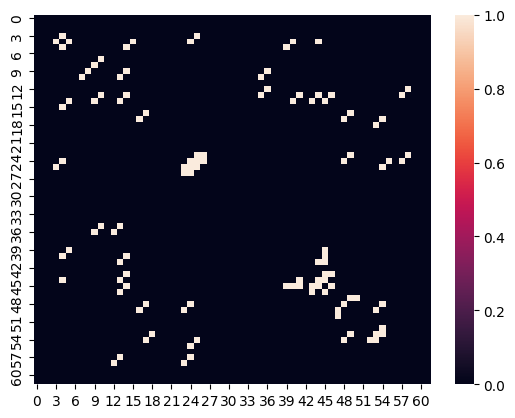

In [ ]:
sns.heatmap(np.array(list_adj_mat).mean(axis=0))
plt.title(f"Stability of adjacency matrix.\n Proportion of occurence on a {n_splits} Cross Validation.\n {"inter" if inter else id_p[i]} case.")

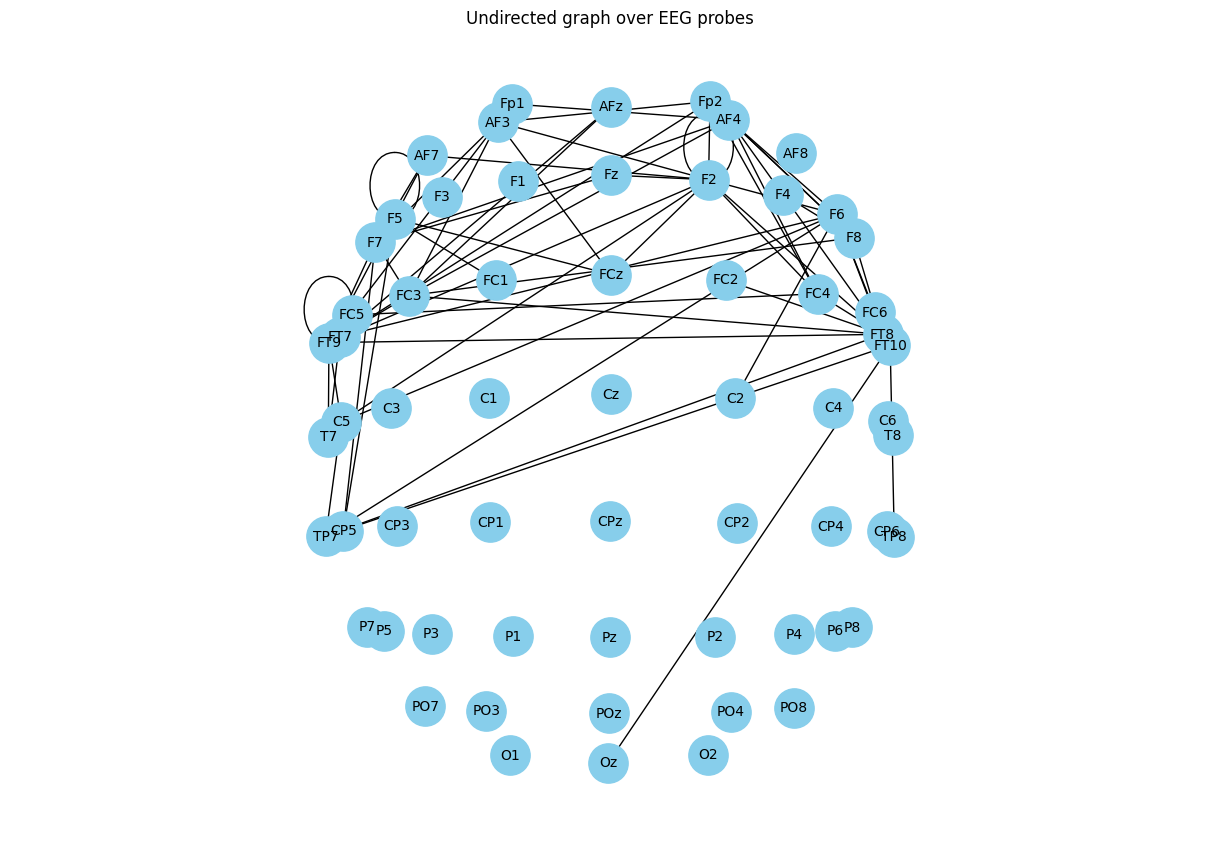

In [ ]:
G = nx.Graph()

# création des noeuds sans noms visibles
G.add_nodes_from([i for i in range(62)])

G.add_edges_from(unique_edges)

# positions
emb = {i : pos[i][:2] for i in range(62)}

# Dictionnaire de labels à attribuer après
labels = {i : str(names[i]) for i in range(62)}

position = nx.get_node_attributes(G, "pos")

# ----- Affichage du graphe -----
scale = 2
plt.figure(figsize=(6*scale,4*scale))
nx.draw(
    G,
    pos = emb,
    labels=labels,
    with_labels=True,
    node_size=800,
    font_size=10,
    edge_color="black",
    node_color="skyblue"
)
plt.title("Undirected graph over EEG probes")
plt.axis("equal")
plt.savefig("graphe.png")
plt.show()

In [ ]:
import plotly.graph_objects as go

G = nx.Graph()

G.add_nodes_from([i for i in range(62)])
G.add_edges_from(unique_edges)

scale = 2
emb = {i: pos[i][:3] * scale for i in range(62)}

labels = {i: str(names[i]) for i in range(62)}

# Coordonnées des noeuds
xs = [emb[i][0] for i in G.nodes()]
ys = [emb[i][1] for i in G.nodes()]
zs = [emb[i][2] for i in G.nodes()]

# Tracer les arêtes
edge_x = []
edge_y = []
edge_z = []
for u, v in G.edges():
    edge_x += [emb[u][0], emb[v][0], None]
    edge_y += [emb[u][1], emb[v][1], None]
    edge_z += [emb[u][2], emb[v][2], None]

edge_trace = go.Scatter3d(
    x=edge_x, y=edge_y, z=edge_z,
    mode='lines',
    line=dict(width=2, color='black')
)

node_trace = go.Scatter3d(
    x=xs, y=ys, z=zs,
    mode='markers+text',
    text=[labels[i] for i in G.nodes()],
    textposition="top center",
    marker=dict(size=8, color='skyblue')
)

fig = go.Figure(data=[edge_trace, node_trace])
fig.update_layout(
    title=f"Interactive 3D graph for {name_part} 🧠",
    showlegend=False,
    scene=dict(xaxis_visible=False, yaxis_visible=False, zaxis_visible=False)
)

fig.show()
fig.write_html(f"/content/seegnature_ECML26/graphs/graph_inter{name_part}.html")

In [ ]:
G = nx.DiGraph()
G.add_nodes_from([i for i in range(62)])
G.add_edges_from([(u, v) for u, v in unique_edges])

scale = 2
emb = {i: pos[i][:3] * scale for i in range(62)}
labels = {i: str(names[i]) for i in range(62)}

xs = [emb[i][0] for i in G.nodes()]
ys = [emb[i][1] for i in G.nodes()]
zs = [emb[i][2] for i in G.nodes()]

# ===== Calcul du out_degree =====
out_degrees = dict(G.out_degree())
node_colors = [out_degrees[i] for i in G.nodes()]

# ===== Arêtes =====
edge_x, edge_y, edge_z = [], [], []

for (u, v) in G.edges():
    edge_x += [emb[u][0], emb[v][0], None]
    edge_y += [emb[u][1], emb[v][1], None]
    edge_z += [emb[u][2], emb[v][2], None]

edge_trace = go.Scatter3d(
    x=edge_x, y=edge_y, z=edge_z,
    mode='lines',
    line=dict(width=3, color='gray')
)

# ===== Flèches directionnelles =====
cone_x, cone_y, cone_z = [], [], []
cone_u, cone_v, cone_w = [], [], []

for (u, v) in G.edges():
    start = emb[u]
    end = emb[v]
    direction = end - start
    direction = direction / np.linalg.norm(direction) * 0.1

    cone_x.append(end[0])
    cone_y.append(end[1])
    cone_z.append(end[2])
    cone_u.append(direction[0])
    cone_v.append(direction[1])
    cone_w.append(direction[2])

cone_trace = go.Cone(
    x=cone_x, y=cone_y, z=cone_z,
    u=cone_u, v=cone_v, w=cone_w,
    sizemode="scaled", sizeref=0.2,
    showscale=False,
    colorscale="Greys",
    anchor="tip"
)

# ===== Trace des noeuds =====
node_trace = go.Scatter3d(
    x=xs, y=ys, z=zs,
    mode='markers+text',
    text=[labels[i] for i in G.nodes()],
    textposition="top center",
    marker=dict(
        size=8,
        color=node_colors,
        colorscale='Plasma',
        showscale=True,
        colorbar=dict(title="Out-degree")
    )
)

# ===== Figure =====
fig = go.Figure(data=[edge_trace, cone_trace, node_trace])

fig.update_layout(
    title="3D Directed graphs",
    showlegend=False,
    scene=dict(xaxis_visible=False, yaxis_visible=False, zaxis_visible=False)
)

fig.show()
fig.write_html(f"/content/seegnature_ECML26/graphs/graph_3D_directed_{name_part}.html")

/tmp/ipykernel_3443/1171194052.py:39: RuntimeWarning:

invalid value encountered in divide

